In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

In [27]:
def TSA_Precheck_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/1 queue for TSA Precheck.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served.
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times assuming an normal distribution
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    server_one_available_times = [0]



    # Compute finish times
    ft = np.zeros(ncust)
    ft[0] = at[0] + st[0]  # First customer's finish time

    # compute finish time for each customer as the larger of
    # arrival time plus service time (if no wait)
    # finish time of previous customer plus service time (if wait)
    for i in range(1, ncust):
        if at[i] < ft[i - 1]:
            wt[i] = ft[i - 1] - at[i]
            ft[i] = ft[i - 1] + st[i]
        else:
            wt[i] = 0
            ft[i] = at[i] + st[i]

    return at, ft, st, wt

In [28]:
def Regular_Security_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/M/3 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]
    server_three_available_times = [0]


    for i in range(ncust):
        # Find the earliest available server
        if server_one_available_times[-1] <= server_two_available_times[-1] and server_one_available_times[-1] <= server_three_available_times[-1]:
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        elif server_two_available_times[-1] <= server_three_available_times[-1]:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

        else:
            earliest_available_time = server_three_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]
            server_three_available_times.append(ft[i])


    return at, ft, st, wt

In [29]:
def Two_Lane_Security(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/2 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """

    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]


    for i in range(ncust):
        # Find the earliest available server
        if server_one_available_times[-1] <= server_two_available_times[-1]:
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        else:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

    return at, ft, st, wt

In [30]:
def TSA_Customers_By_Price(price):
    """
    Returns the number of customers that use TSA Precheck as a result of price

    Inputs:
       Price: price of TSA Precheck
    Outputs:
       ncust: percentage of customers that use TSA Precheck as a result of price
    """

    assumption_dollar_per_percentage = 1.115 #Calculated from the 30% of travelers at $78 dollar cost

    return max(0, min(1, (100 - price/assumption_dollar_per_percentage)/100))


Price of TSA PreCheck: $76.75 https://tsaenrollmentbyidemia.tsa.dhs.gov/programs/precheck

Number of TSA travelers that use precheck: 30%, from washington post, which is a little suspect.

Assumptions: at $0, every traveler would get it, and make the format linear from there.

In [31]:
print(TSA_Customers_By_Price(0))

1


Our standard service rate is set at 1.9701 passengers per minute
Our Precheck service rate is set to 2.62023 passangers per minute

In [32]:
customer_count = 1000
service_time_average_regular_security = 0.51
service_time_std_regular_security = .2
service_time_average_Precheck = 0.382
service_time_std_Precheck = 0.1
total_arrival_rate_per_minute = 8
tsa_precheck_cost=78



precheck_percentage = TSA_Customers_By_Price(78)

precheck_arrival_rate=total_arrival_rate_per_minute*precheck_percentage
standard_arrival_rate=total_arrival_rate_per_minute*(1-precheck_percentage)

standard_at, standard_ft, standard_st, standard_wt = Regular_Security_Line(standard_arrival_rate, service_time_average_regular_security, service_time_std_regular_security, int((1-precheck_percentage)*customer_count))
precheck_at, precheck_ft, precheck_st, precheck_wt = TSA_Precheck_Line(precheck_arrival_rate, service_time_average_Precheck, service_time_std_Precheck, int((precheck_percentage)*customer_count))

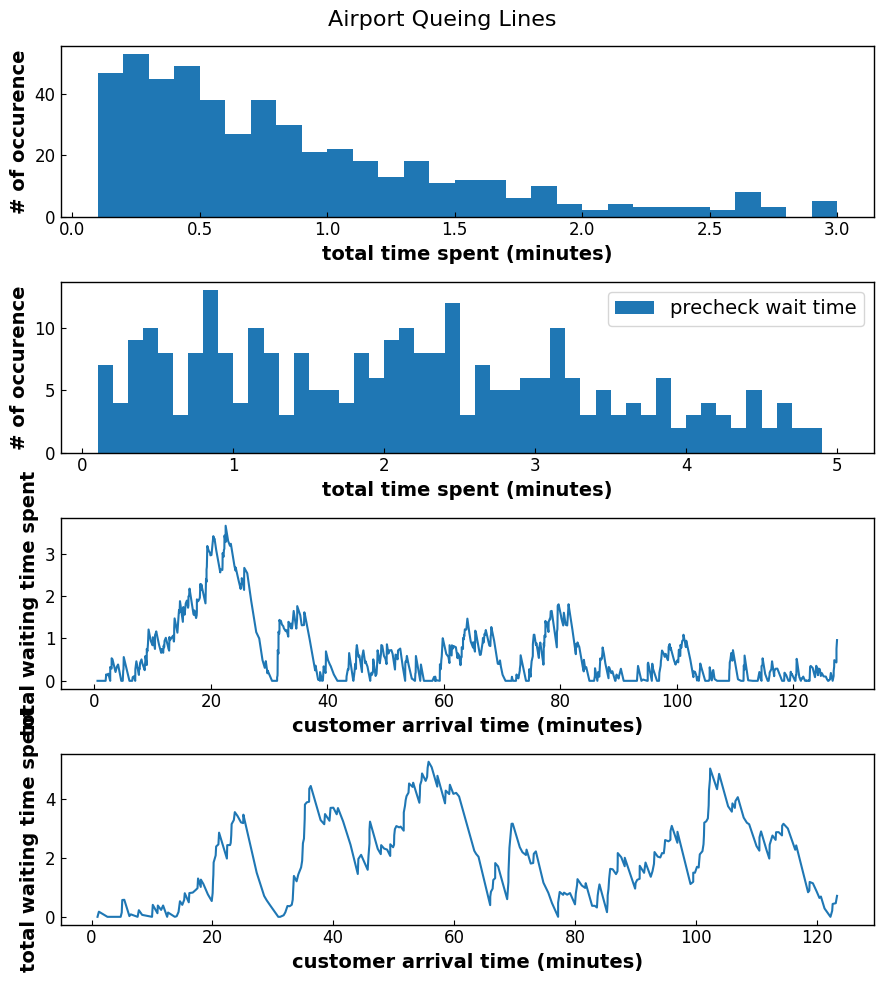

In [33]:
# Compare simulation to Poisson distribution
fig, axs = plt.subplots(4, 1, figsize=(9, 10), tight_layout=True)

bin_size = .1

# Plot histogram of waiting times
axs[0].hist(
    standard_wt,
    bins=np.arange(.1, np.floor(np.max(standard_wt)) + bin_size, bin_size),
    label="standard wait time",
)
axs[0].set(ylabel="# of occurence")
axs[0].set(xlabel="total time spent (minutes)")

# Plot histogram of waiting times
axs[1].hist(
    precheck_wt,
    bins=np.arange(.1, np.floor(np.max(precheck_wt)) + bin_size, bin_size),
    label="precheck wait time",
)
axs[1].set(ylabel="# of occurence")
axs[1].set(xlabel="total time spent (minutes)")


# Plot total wait time
axs[2].plot(standard_at, standard_wt)
axs[2].set(xlabel="customer arrival time (minutes)")
axs[2].set(ylabel="total waiting time spent")

# Plot total wait time
axs[3].plot(precheck_at, precheck_wt)
axs[3].set(xlabel="customer arrival time (minutes)")
axs[3].set(ylabel="total waiting time spent")

# make legend
axs[1].legend()
plt.suptitle("Airport Queing Lines", fontsize=16)
plt.show()

Try modifying the cost of TSA, offer a 10 dollar discount

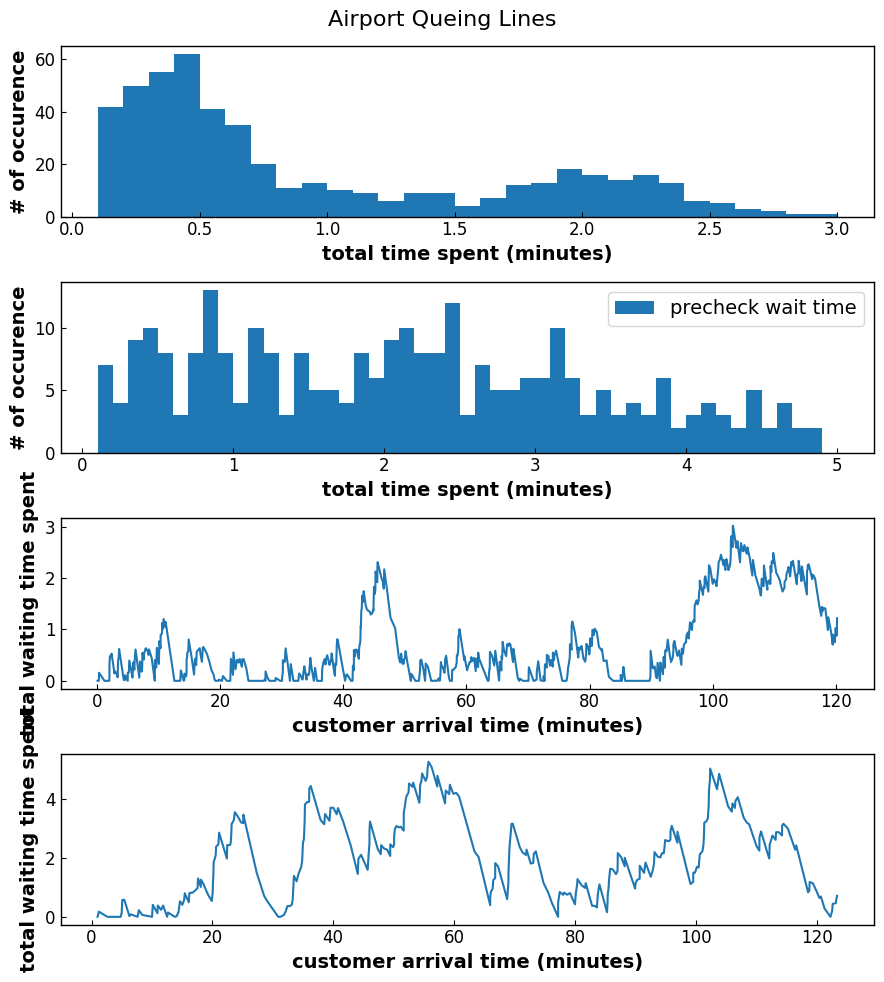

In [34]:
customer_count = 1000
service_time_average_regular_security = 0.51
service_time_std_regular_security = .1
service_time_average_Precheck = 0.30
service_time_std_Precheck = 0.05
total_arrival_rate_per_minute = 8
tsa_precheck_cost= 73



precheck_percentage = TSA_Customers_By_Price(tsa_precheck_cost)

precheck_arrival_rate=total_arrival_rate_per_minute*precheck_percentage
standard_arrival_rate=total_arrival_rate_per_minute*(1-precheck_percentage)

standard_at, standard_ft, standard_st, standard_wt = Regular_Security_Line(standard_arrival_rate, service_time_average_regular_security, service_time_std_regular_security, int((1-precheck_percentage)*customer_count))

# Compare simulation to Poisson distribution
fig, axs = plt.subplots(4, 1, figsize=(9, 10), tight_layout=True)

bin_size = .1

# Plot histogram of waiting times
axs[0].hist(
    standard_wt,
    bins=np.arange(.1, np.floor(np.max(standard_wt)) + bin_size, bin_size),
    label="standard wait time",
)
axs[0].set(ylabel="# of occurence")
axs[0].set(xlabel="total time spent (minutes)")

# Plot histogram of waiting times
axs[1].hist(
    precheck_wt,
    bins=np.arange(.1, np.floor(np.max(precheck_wt)) + bin_size, bin_size),
    label="precheck wait time",
)
axs[1].set(ylabel="# of occurence")
axs[1].set(xlabel="total time spent (minutes)")


# Plot total wait time
axs[2].plot(standard_at, standard_wt)
axs[2].set(xlabel="customer arrival time (minutes)")
axs[2].set(ylabel="total waiting time spent")

# Plot total wait time
axs[3].plot(precheck_at, precheck_wt)
axs[3].set(xlabel="customer arrival time (minutes)")
axs[3].set(ylabel="total waiting time spent")

# make legend
axs[1].legend()
plt.suptitle("Airport Queing Lines", fontsize=16)
plt.show()

In [36]:
total_standard_wait_time = np.sum(standard_wt)
total_precheck_wait_time = np.cumsum(precheck_wt)
print(total_standard_wait_time)
print(total_precheck_wait_time[-1])

480.1116895854234
614.2089092074858


In [37]:
def run_cost_analysis(price_range, customer_count, service_params, arrival_rate, num_simulations=10):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = TSA_Customers_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = Regular_Security_Line(
                    standard_arrival_rate,
                    service_params['regular_mean'],
                    service_params['regular_std'],
                    standard_customers
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = TSA_Precheck_Line(
                    precheck_arrival_rate,
                    service_params['precheck_mean'],
                    service_params['precheck_std'],
                    precheck_customers
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = total_wait_time / total_customers_served if total_customers_served > 0 else 0

            price_results.append({
                'price': price,
                'precheck_percentage': precheck_percentage,
                'total_wait_time': total_wait_time,
                'avg_wait_time': avg_wait_time,
                'standard_customers': standard_customers,
                'precheck_customers': precheck_customers
            })

        # Average results across simulations for this price
        avg_results = {
            'price': price,
            'precheck_percentage': np.mean([r['precheck_percentage'] for r in price_results]),
            'total_wait_time_mean': np.mean([r['total_wait_time'] for r in price_results]),
            'total_wait_time_std': np.std([r['total_wait_time'] for r in price_results]),
            'avg_wait_time_mean': np.mean([r['avg_wait_time'] for r in price_results]),
            'avg_wait_time_std': np.std([r['avg_wait_time'] for r in price_results]),
            'standard_customers_mean': np.mean([r['standard_customers'] for r in price_results]),
            'precheck_customers_mean': np.mean([r['precheck_customers'] for r in price_results])
        }

        results.append(avg_results)

    return pd.DataFrame(results)

In [41]:
def run_cost_analysis_even_lanes(price_range, customer_count, service_params, arrival_rate, num_simulations=10):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = TSA_Customers_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = Two_Lane_Security(
                    standard_arrival_rate,
                    service_params['regular_mean'],
                    service_params['regular_std'],
                    standard_customers
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = Two_Lane_Security(
                    precheck_arrival_rate,
                    service_params['precheck_mean'],
                    service_params['precheck_std'],
                    precheck_customers
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = total_wait_time / total_customers_served if total_customers_served > 0 else 0

            price_results.append({
                'price': price,
                'precheck_percentage': precheck_percentage,
                'total_wait_time': total_wait_time,
                'avg_wait_time': avg_wait_time,
                'standard_customers': standard_customers,
                'precheck_customers': precheck_customers
            })

        # Average results across simulations for this price
        avg_results = {
            'price': price,
            'precheck_percentage': np.mean([r['precheck_percentage'] for r in price_results]),
            'total_wait_time_mean': np.mean([r['total_wait_time'] for r in price_results]),
            'total_wait_time_std': np.std([r['total_wait_time'] for r in price_results]),
            'avg_wait_time_mean': np.mean([r['avg_wait_time'] for r in price_results]),
            'avg_wait_time_std': np.std([r['avg_wait_time'] for r in price_results]),
            'standard_customers_mean': np.mean([r['standard_customers'] for r in price_results]),
            'precheck_customers_mean': np.mean([r['precheck_customers'] for r in price_results])
        }

        results.append(avg_results)

    return pd.DataFrame(results)

In [42]:
def plot_results(results_df):
    """
    Create visualizations of the cost analysis results
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Total Wait Time vs Price
    ax1.errorbar(results_df['price'], results_df['total_wait_time_mean'],
                yerr=results_df['total_wait_time_std'], marker='o', capsize=5)
    ax1.set_xlabel('TSA Precheck Price ($)')
    ax1.set_ylabel('Total Wait Time (minutes)')
    ax1.set_title('Total System Wait Time vs TSA Price')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Average Wait Time vs Price
    ax2.errorbar(results_df['price'], results_df['avg_wait_time_mean'],
                yerr=results_df['avg_wait_time_std'], marker='o', capsize=5, color='orange')
    ax2.set_xlabel('TSA Precheck Price ($)')
    ax2.set_ylabel('Average Wait Time per Customer (minutes)')
    ax2.set_title('Average Wait Time vs TSA Price')
    ax2.grid(True, alpha=0.3)

    # Plot 3: Precheck Adoption vs Price
    ax3.plot(results_df['price'], results_df['precheck_percentage'] * 100, marker='o', color='green')
    ax3.set_xlabel('TSA Precheck Price ($)')
    ax3.set_ylabel('Precheck Adoption (%)')
    ax3.set_title('TSA Precheck Adoption vs Price')
    ax3.grid(True, alpha=0.3)

    # Plot 4: Customer Distribution
    ax4.plot(results_df['price'], results_df['standard_customers_mean'],
             marker='o', label='Regular Security', color='red')
    ax4.plot(results_df['price'], results_df['precheck_customers_mean'],
             marker='s', label='TSA Precheck', color='blue')
    ax4.set_xlabel('TSA Precheck Price ($)')
    ax4.set_ylabel('Number of Customers')
    ax4.set_title('Customer Distribution by Line')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Running TSA cost analysis...
Testing price: $0
Testing price: $10
Testing price: $20
Testing price: $30
Testing price: $40
Testing price: $50
Testing price: $60
Testing price: $70
Testing price: $80
Testing price: $90
Testing price: $100
Testing price: $110

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean
0       0                1.000            129079.259             129.079
1      10                0.910            100089.510             100.190
2      20                0.821             74840.977              74.916
3      30                0.731             55989.959              56.046
4      40                0.641             37683.421              37.721
5      50                0.552             23350.309              23.374
6      60                0.462             12454.099              12.467
7      70                0.372              4155.927               4.160
8      80                0.283              1903.788               

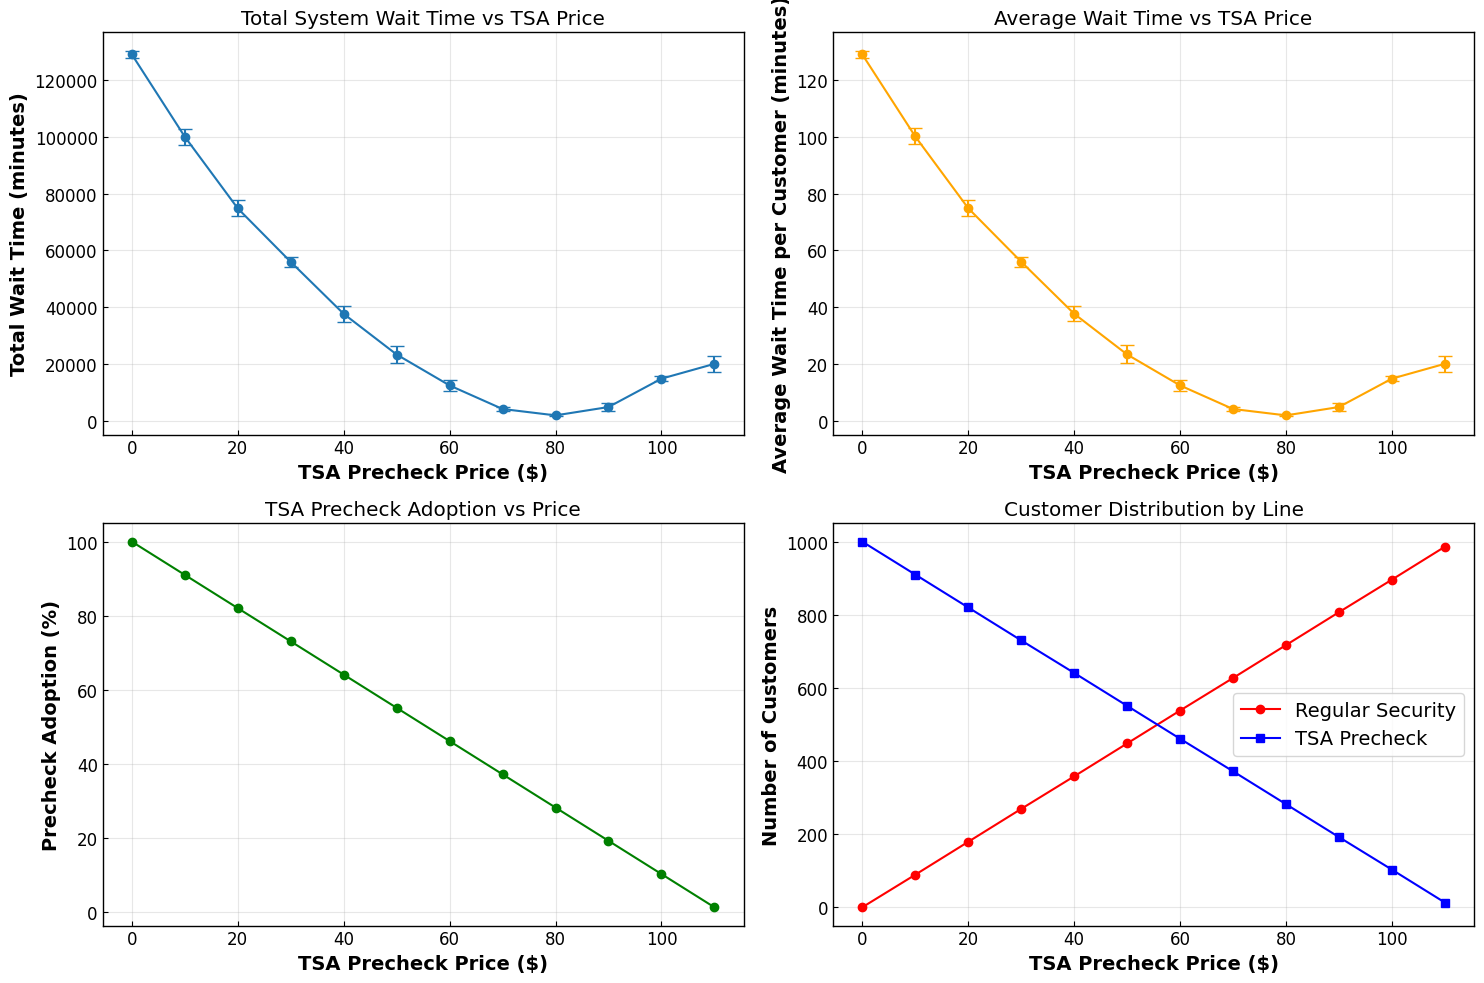

In [43]:
# Define test parameters
price_range = np.arange(0, 120, 10)  # Test prices from $0 to $110 in $10 increments
customer_count = 1000

service_params = {
    'regular_mean': 0.51,
    'regular_std': 0.2,
    'precheck_mean': 0.382,
    'precheck_std': 0.1
}

total_arrival_rate_per_minute = 8

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)


Running TSA cost analysis...
Testing price: $0
Testing price: $5
Testing price: $10
Testing price: $15
Testing price: $20
Testing price: $25
Testing price: $30
Testing price: $35
Testing price: $40
Testing price: $45
Testing price: $50
Testing price: $55
Testing price: $60
Testing price: $65
Testing price: $70
Testing price: $75
Testing price: $80
Testing price: $85
Testing price: $90
Testing price: $95
Testing price: $100
Testing price: $105
Testing price: $110
Testing price: $115

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean
0       0                1.000             34385.947              34.386
1       5                0.955             28046.325              28.074
2      10                0.910             22244.186              22.266
3      15                0.865             16532.808              16.549
4      20                0.821             13011.791              13.025
5      25                0.776              8468.381     

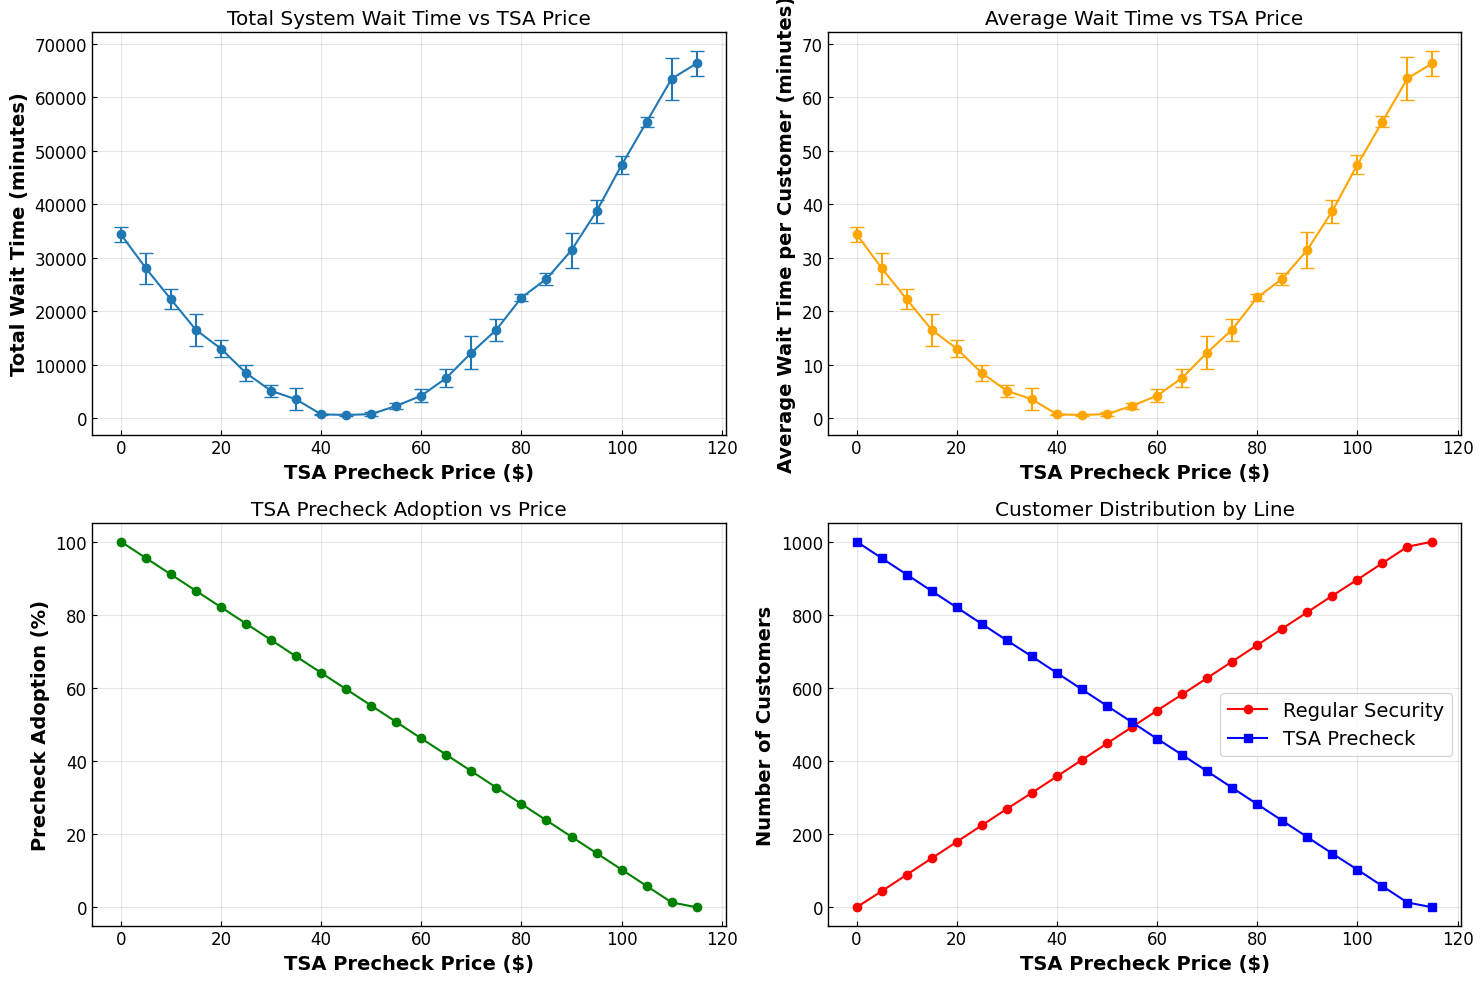

In [44]:
# Define test parameters
price_range = np.arange(0, 120, 5)  # Test prices from $0 to $110 in $10 increments
customer_count = 1000

service_params = {
    'regular_mean': 0.51,
    'regular_std': 0.2,
    'precheck_mean': 0.382,
    'precheck_std': 0.1
}

total_arrival_rate_per_minute = 8

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_even_lanes(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)
